In [1]:
# analysis specific imports
import spacenet as sn

# general imports
import numpy as np
import pandas as pd 
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt 
import os 

# additional imports
os.chdir('../misc')
from normalised_cross_correlation import normalised_cross_correlation

plt.rcParams['figure.dpi'] = 200

max_r=500

netPCF_kwargs = dict(spatial_kernel_bandwidth=80,
                    spatial_kernel_n=2,
                    r_min=0, 
                    r_max=max_r, 
                    r_step=5,
                    edge_weight_name='Distance', 
                    return_confidence_interval=True,
                    low_memory=False,
                    verbose=False,
                    n_jobs=6) 

scatter_kwargs=dict(linewidths=0.1,edgecolors='black')
visualise_paras = dict(edge_width=0.3,marker_size=0,add_node_cbar=False,scatter_kwargs=scatter_kwargs,edge_vmin=-200,edge_vmax=500,edge_weight_name='Distance') 
scalebar_kwargs = dict(size=200, label='',loc='lower right',pad = 1.5,frameon=False,size_vertical=10,zorder=1000)

# grab the data
spiral_df = pd.read_csv('../data/synthetic_data/spiral_domain.csv')
points_spiral = spiral_df[['x','y']].to_numpy() 
rand_labels_spiral = spiral_df['Random marker (categorical)']
periodic_labels_spiral = spiral_df['Marker (categorical)']

points_spiral = spiral_df[['x','y']].to_numpy() 
points_spiral= (points_spiral/2 + 500) +np.array([-25,50])

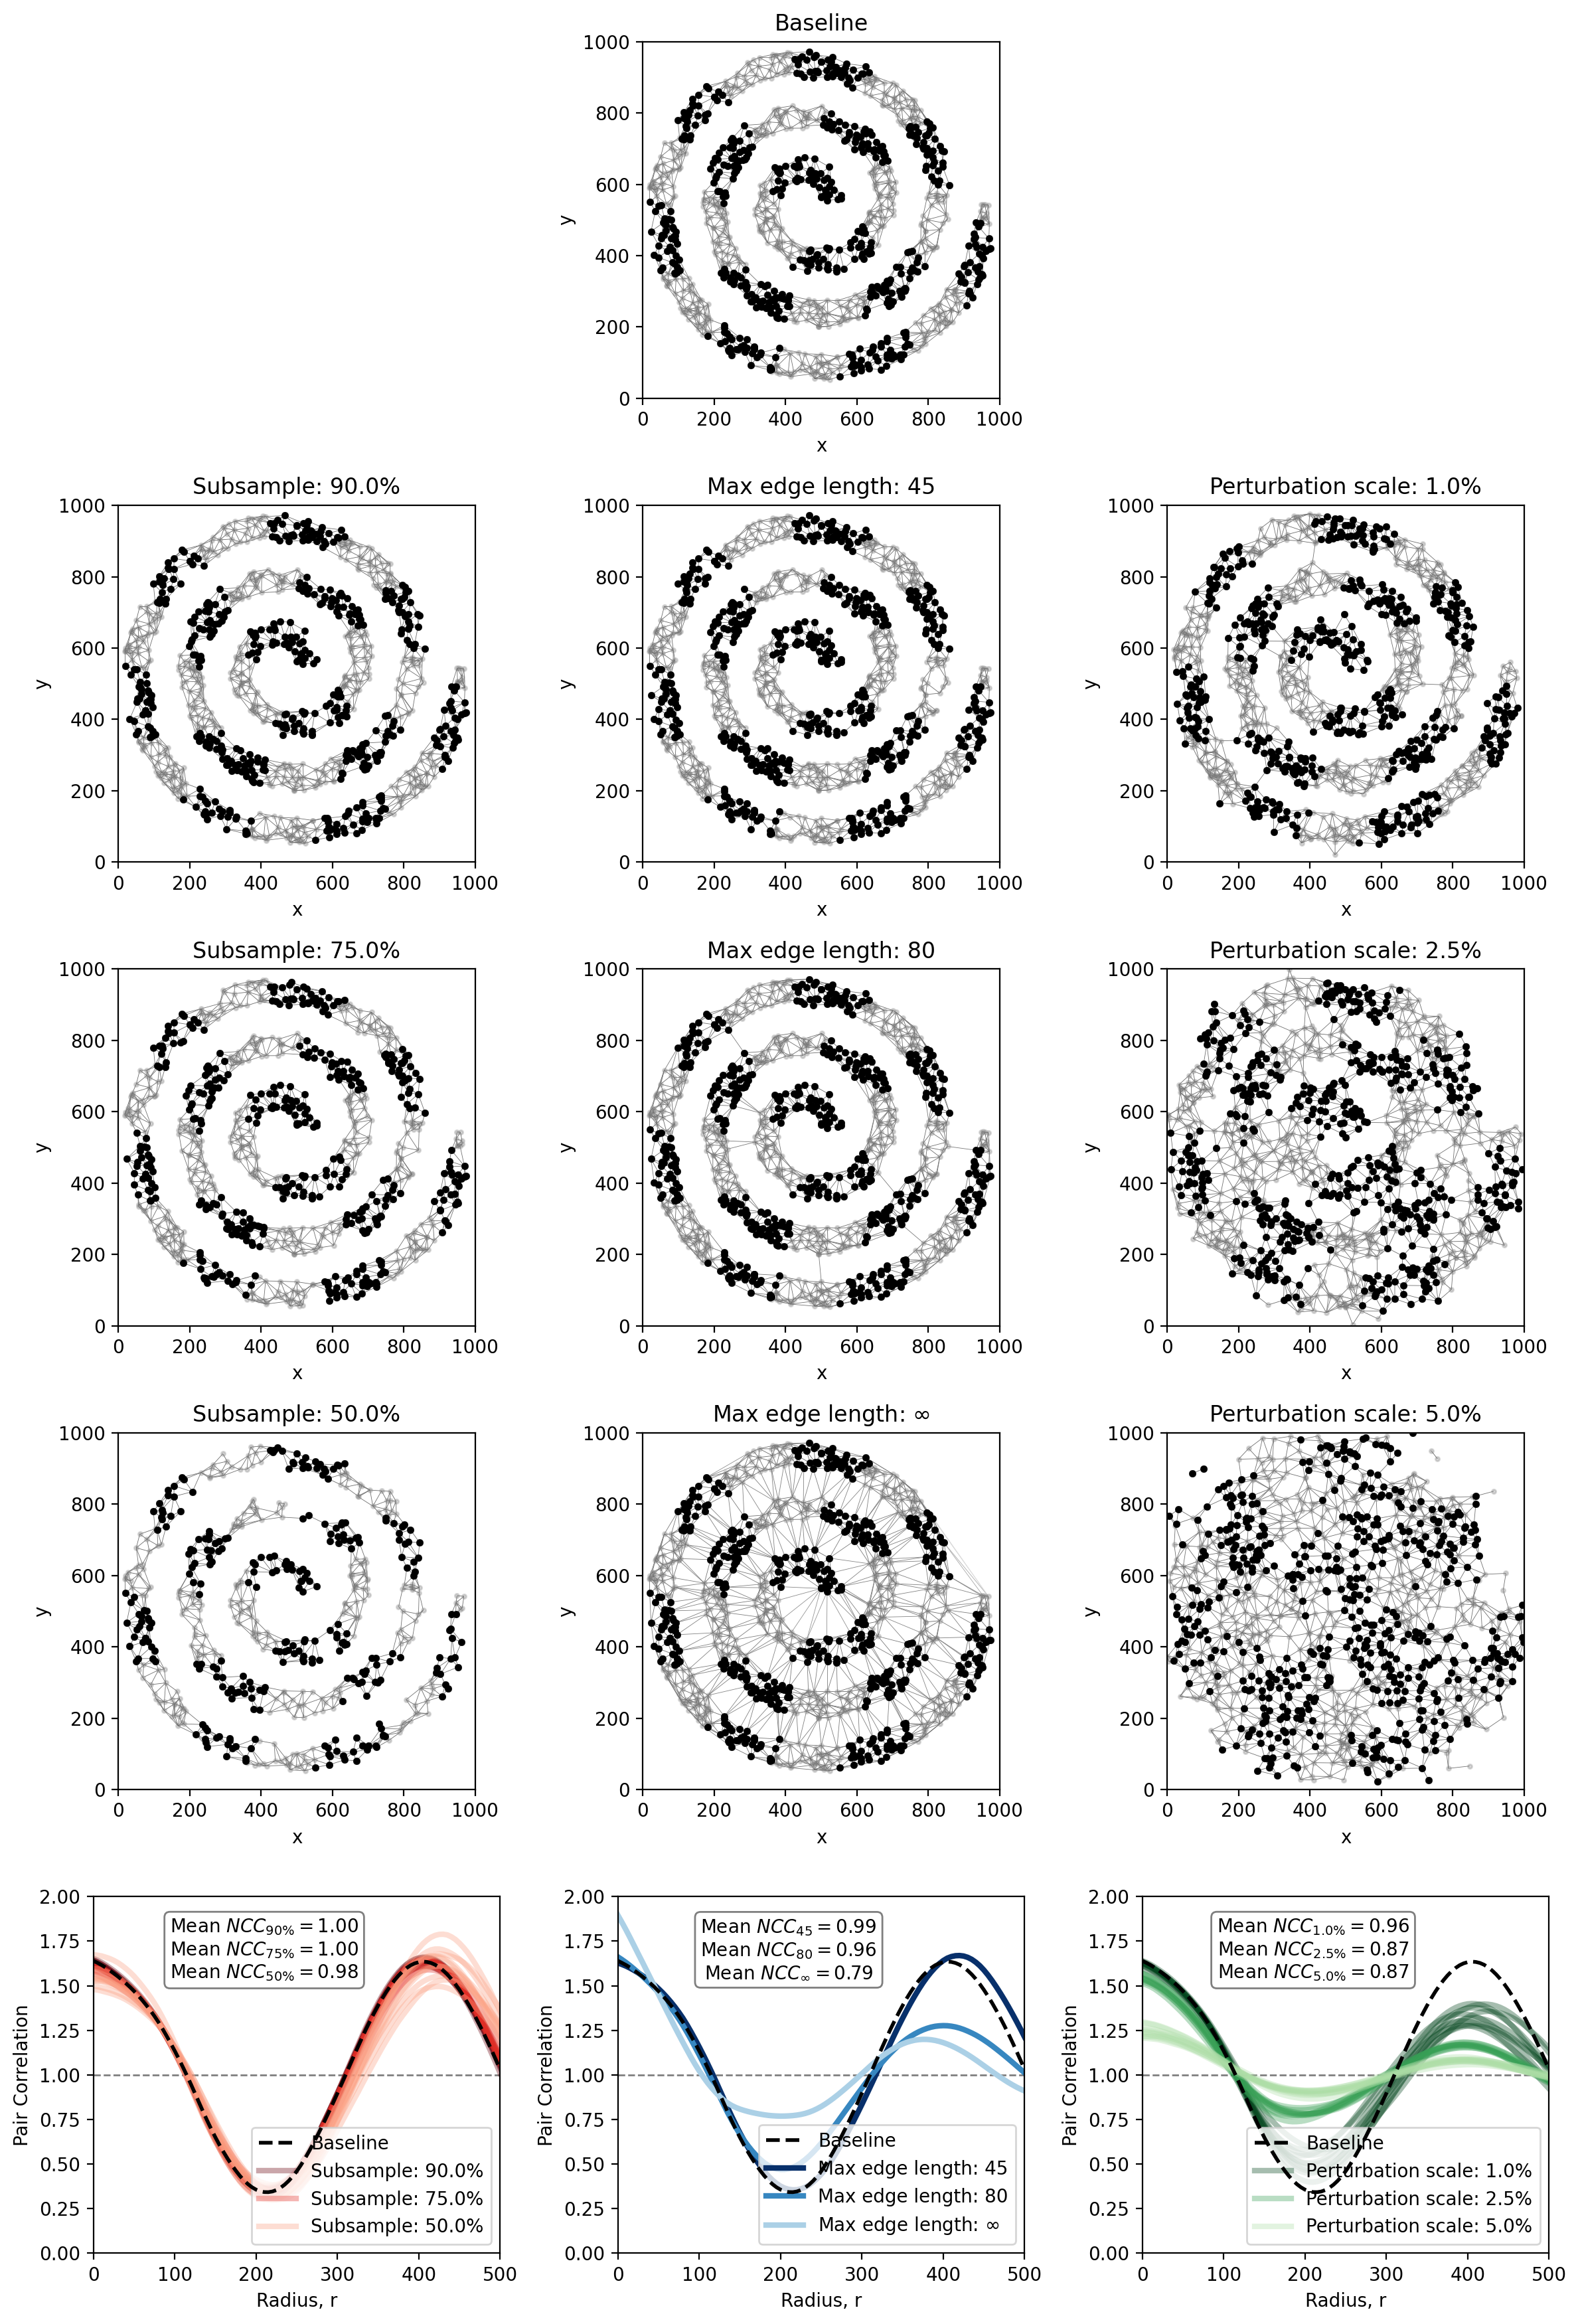

In [2]:
# control runs
run_edge = True
run_perturb = True
run_subsample=True

number_of_trials = 10


# grabbing node indices
object_indices_A = np.where(periodic_labels_spiral=='A')[0]
object_indices_B = object_indices_A

background_points = points_spiral[periodic_labels_spiral=='B']
spiral_points = points_spiral[object_indices_A]


# setting up figure
plot_scale = 0.8
fig, ax = plt.subplots(5, 3, figsize=(15 * plot_scale, 22 * plot_scale))


ax[0,0].set_axis_off()
ax[0,2].set_axis_off()

G_baseline = sn.utils.spatial_network_from_points(points_spiral,network_type='delaunay',max_edge_distance=60)
sn.utils.plot_spatial_network(G_baseline,ax=ax[0,1],**visualise_paras)

ax[0,1].scatter(background_points[:,0],background_points[:,1],color='tab:grey',s=5,alpha=0.3)
ax[0,1].scatter(spiral_points[:,0],spiral_points[:,1],color='black',s=15,edgecolors='black',linewidths=0.1)
ax[0,1].set_axis_on()
ax[0,1].set_xlim(0, 1000)   
ax[0,1].set_ylim(0, 1000)
ax[0,1].set_title('Baseline') 
ax[0,1].set_xlabel('x')
ax[0,1].set_ylabel('y')

netPCF_kwargs_perturb = netPCF_kwargs | dict(return_confidence_interval=False)

object_indices_A = np.where(periodic_labels_spiral=='A')[0]
object_indices_B = object_indices_A
r_baseline,g_baseline = sn.point_patterns.cross_pair_correlation_function(G_baseline,
                                                            nodes_a=object_indices_A,
                                                            nodes_b=object_indices_B,
                                                            **netPCF_kwargs_perturb)

ax[4,0].axhline(1, color='gray', linestyle='--', linewidth=1)    
ax[4,0].plot(r_baseline,g_baseline,label='Baseline',color='black',linestyle='--',zorder=500,linewidth=2) 
ax[4,0].set_xlabel('Radius, r')
ax[4,0].set_ylabel('Pair Correlation')
ax[4,0].set_xlim(0, max_r)  
ax[4,0].set_ylim(0, 2)


ax[4,1].axhline(1, color='gray', linestyle='--', linewidth=1)    
ax[4,1].plot(r_baseline,g_baseline,label='Baseline',color='black',linestyle='--',zorder=500,linewidth=2) 
ax[4,1].set_xlabel('Radius, r')
ax[4,1].set_ylabel('Pair Correlation')
ax[4,1].set_xlim(0, max_r)  
ax[4,1].set_ylim(0, 2)

ax[4,2].axhline(1, color='gray', linestyle='--', linewidth=1)    
ax[4,2].plot(r_baseline,g_baseline,label='Baseline',color='black',linestyle='--',zorder=500,linewidth=2) 
ax[4,2].set_xlabel('Radius, r')
ax[4,2].set_ylabel('Pair Correlation')
ax[4,2].set_xlim(0, max_r)  
ax[4,2].set_ylim(0, 2)

correlation_coeffs = dict()

### submsampling
subsample_density= [0.90,0.75,0.5]
colors_sample = plt.cm.Reds_r(np.linspace(0,1,len(subsample_density)+1))
if run_subsample:
    correlation_coeffs['sub']=dict()
    for i,scale in enumerate(subsample_density):
        list_of_ccs=[]
        trials=0
        while trials < number_of_trials:
            # perturb points
            sample_mask = np.random.choice(len(points_spiral), size=int(len(points_spiral)*scale), replace=False)
            
            
            points_spiral_perturb = points_spiral[sample_mask]
            periodic_labels_spiral_perturb = periodic_labels_spiral[sample_mask]
            background_points_perturb  = points_spiral_perturb[periodic_labels_spiral_perturb=='B']
            
            object_indices_A_perturb = np.where(periodic_labels_spiral_perturb=='A')[0]
            spiral_points_perturb  = points_spiral_perturb[object_indices_A_perturb]
            
            
            G_ppp_cluster = sn.utils.spatial_network_from_points(points_spiral_perturb,network_type='delaunay',max_edge_distance=60)
            
            if nx.number_connected_components(G_ppp_cluster) == 1:    
                if trials==0:
                    sn.utils.plot_spatial_network(G_ppp_cluster,ax=ax[i+1,0],**visualise_paras)
                    
                    ax[i+1,0].scatter(background_points_perturb[:,0],background_points_perturb[:,1],color='tab:grey',s=5,alpha=0.3)
                    ax[i+1,0].scatter(spiral_points_perturb[:,0],spiral_points_perturb[:,1],color='black',s=15,edgecolors='black',linewidths=0.1)
                    ax[i+1,0].set_axis_on()
                    ax[i+1,0].set_aspect('equal')  
                    ax[i+1,0].set_xlim(0, 1000)   
                    ax[i+1,0].set_ylim(0, 1000)
                    ax[i+1,0].set_title(f'Subsample: {scale*100}%')
                    ax[i+1,0].set_xlabel('x')
                    ax[i+1,0].set_ylabel('y')
                

                r_temp,g_temp= sn.point_patterns.cross_pair_correlation_function(G_ppp_cluster,
                                                                nodes_a=object_indices_A_perturb,
                                                                nodes_b=object_indices_A_perturb,
                                                                **netPCF_kwargs_perturb)
                
                
                list_of_ccs.append(normalised_cross_correlation(g_baseline,g_temp)[0])
                ax[4,0].plot(r_temp,g_temp,color=colors_sample[i],alpha=0.35,label=f'Subsample: {scale*100}%' if trials==0 else "",linewidth=3) 
                trials+=1
        correlation_coeffs['sub'][scale]=list_of_ccs
    ax[4,0].legend(loc='lower right')
    
    average_NCCS=np.mean(np.array(list(correlation_coeffs['sub'].values())),axis=1)
    ncc_text = 'Mean $NCC_{90\\%}=$' + f'{average_NCCS[0]:.2f}' +'\n'+ 'Mean $NCC_{75\\%}=$' + f'{average_NCCS[1]:.2f}' + '\n' + 'Mean $NCC_{50\\%}=$' + f'{average_NCCS[2]:.2f}'
    ax[4,0].text(210,1.7,ncc_text,va='center',ha='center',fontsize=10,bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))


### edge pruning
max_edge_lengths = [45,80,np.inf]
colors_edge= plt.cm.Blues_r(np.linspace(0,1,len(max_edge_lengths)+1))

if run_edge:
    correlation_coeffs['edge']=dict()
    for i,edge_length in enumerate(max_edge_lengths):
            # perturb points
            
            G_ppp_cluster = sn.utils.spatial_network_from_points(points_spiral,network_type='delaunay',max_edge_distance=edge_length)
            sn.utils.plot_spatial_network(G_ppp_cluster,ax=ax[i+1,1],**visualise_paras)
            
            ax[i+1,1].scatter(background_points[:,0],background_points[:,1],color='tab:grey',s=5,alpha=0.3)
            ax[i+1,1].scatter(spiral_points[:,0],spiral_points[:,1],color='black',s=15,edgecolors='black',linewidths=0.1)
            ax[i+1,1].set_axis_on()
            ax[i+1,1].set_aspect('equal')       
            ax[i+1,1].set_xlim(0, 1000)   
            ax[i+1,1].set_ylim(0, 1000)
            ax[i+1,1].set_aspect('equal') 
            ax[i+1,1].set_xlabel('x')
            ax[i+1,1].set_ylabel('y')      

            if edge_length == np.inf:
                this_label = f'Max edge length: $\\infty$'

            else:
                this_label = f'Max edge length: {edge_length}'
            ax[i+1,1].set_title(this_label)
            

            r_temp,g_temp= sn.point_patterns.cross_pair_correlation_function(G_ppp_cluster,
                                                            nodes_a=object_indices_A,
                                                            nodes_b=object_indices_B,
                                                            **netPCF_kwargs_perturb)
            
            this_cc = normalised_cross_correlation(g_baseline,g_temp)[0]
            correlation_coeffs['edge'][edge_length] = this_cc
            ax[4,1].plot(r_temp,g_temp,color=colors_edge[i],alpha=1,label=this_label,linewidth=3) 
    ax[4,1].legend(loc='lower right')
    
    for key in correlation_coeffs['edge']:
        correlation_coeffs['edge'][key] = [correlation_coeffs['edge'][key]]
    average_NCCS_edge=np.mean(np.array(list(correlation_coeffs['edge'].values())),axis=1)
    ncc_text_edge = 'Mean $NCC_{45}=$' + f'{average_NCCS_edge[0]:.2f}' +'\n'+ 'Mean $NCC_{80}=$' + f'{average_NCCS_edge[1]:.2f}' + '\n' + 'Mean $NCC_{\\infty}=$' + f'{average_NCCS_edge[2]:.2f}'
    ax[4,1].text(210,1.7,ncc_text_edge,va='center',ha='center',fontsize=10,bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

### Perturbation of points

scale_of_perturbation = [0.01,0.025,0.05]
colors_noise= plt.cm.Greens_r(np.linspace(0,1,len(scale_of_perturbation)+1))

if run_perturb:
    correlation_coeffs['per']=dict()
    for i,scale in enumerate(scale_of_perturbation):
        list_of_ccs = []
        for trial in range(number_of_trials):
            # perturb points
            perturbation = np.random.normal(scale=scale * 1000, size=points_spiral.shape)
            points_spiral_perturb = points_spiral + perturbation
            
            mask = np.logical_and(points_spiral_perturb[:,0]>0,points_spiral_perturb[:,0]<1000) & np.logical_and(points_spiral_perturb[:,1]>0,points_spiral_perturb[:,1]<1000)
            
            these_points_spiral_perturb = points_spiral_perturb[mask]
            these_periodic_labels_spiral = periodic_labels_spiral[mask]
            
        
            background_points_perturb  = these_points_spiral_perturb[these_periodic_labels_spiral=='B']
            spiral_points_perturb  = these_points_spiral_perturb[these_periodic_labels_spiral=='A']
            
            
            these_object_indices_A = np.where(these_periodic_labels_spiral=='A')[0]   
            
            G_ppp_cluster = sn.utils.spatial_network_from_points(these_points_spiral_perturb,network_type='delaunay',max_edge_distance=60)
            if trial==0:
                sn.utils.plot_spatial_network(G_ppp_cluster,ax=ax[i+1,2],**visualise_paras)
                
                ax[i+1,2].scatter(background_points_perturb[:,0],background_points_perturb[:,1],color='tab:grey',s=5,alpha=0.3)
                ax[i+1,2].scatter(spiral_points_perturb[:,0],spiral_points_perturb[:,1],color='black',s=15,edgecolors='black',linewidths=0.1)
                ax[i+1,2].set_axis_on()
                ax[i+1,2].set_aspect('equal',adjustable='box')  
                ax[i+1,2].set_xlim(0, 1000)   
                ax[i+1,2].set_ylim(0, 1000)
                
                ax[i+1,2].set_title(f'Perturbation scale: {scale*100}%')
                ax[i+1,2].set_xlabel('x')
                ax[i+1,2].set_ylabel('y')
            

            r_temp,g_temp= sn.point_patterns.cross_pair_correlation_function(G_ppp_cluster,
                                                            nodes_a=these_object_indices_A,
                                                            nodes_b=these_object_indices_A,
                                                            **netPCF_kwargs_perturb)
            list_of_ccs.append(normalised_cross_correlation(g_baseline,g_temp)[0])
            ax[4,2].plot(r_temp,g_temp,color=colors_noise[i],alpha=0.35,label=f'Perturbation scale: {scale*100}%' if trial==0 else "",linewidth=3) 
        correlation_coeffs['per'][scale]=list_of_ccs
    ax[4,2].legend(loc='lower right')
    average_NCCS_per=np.mean(np.array(list(correlation_coeffs['per'].values())),axis=1)
    ncc_text_per = 'Mean $NCC_{1.0\\%}=$' + f'{average_NCCS_per[0]:.2f}' +'\n'+ 'Mean $NCC_{2.5\\%}=$' + f'{average_NCCS_per[1]:.2f}' + '\n' + 'Mean $NCC_{5.0\\%}=$' + f'{average_NCCS_per[2]:.2f}'
    ax[4,2].text(210,1.7,ncc_text_per,va='center',ha='center',fontsize=10,bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    
plt.tight_layout()
#fig.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/figures/robustness_w_quant.png',dpi=300)
#fig.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/figures/robustness_w_quant.pdf',dpi=300)


Text(0.5, 0, 'Perturbation scale')

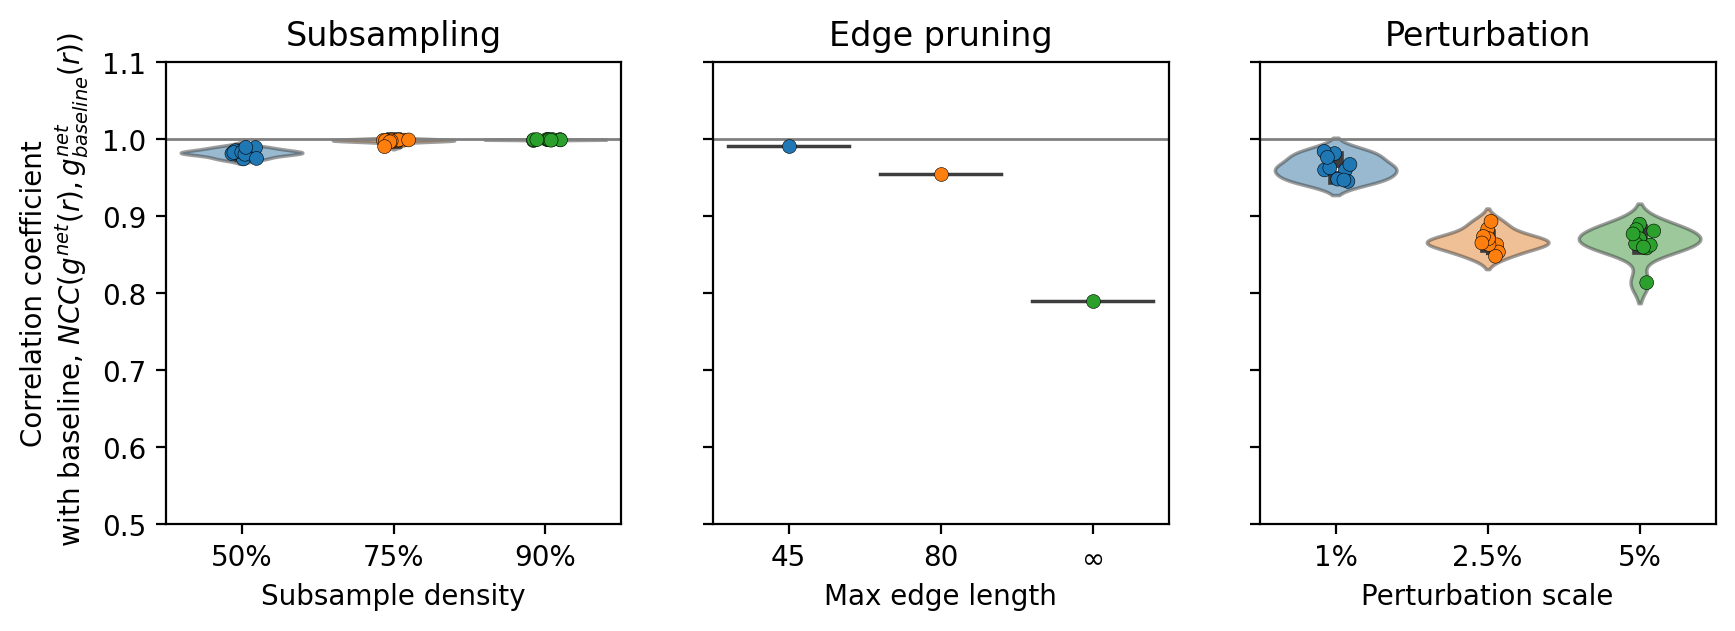

In [3]:
# all NCC values for runs

fig,ax=plt.subplots(1,3,figsize=(10, 3),sharey=True)

sns.stripplot(data=correlation_coeffs['sub'],ax=ax[0],edgecolor='black',linewidth=0.2)
sns.violinplot(data=correlation_coeffs['sub'],ax=ax[0],alpha=0.5)   

sns.stripplot(data=correlation_coeffs['edge'],ax=ax[1],edgecolor='black',linewidth=0.2)
sns.violinplot(data=correlation_coeffs['edge'],ax=ax[1],alpha=0.5)   

sns.stripplot(data=correlation_coeffs['per'],ax=ax[2],edgecolor='black',linewidth=0.2)
sns.violinplot(data=correlation_coeffs['per'],ax=ax[2],alpha=0.5)   

ax[0].set_ylim([0.5,1.1])
ax[1].set_ylim([0.5,1.1])
ax[2].set_ylim([0.5,1.1])

ax[0].axhline(1,color='gray', linestyle='-', linewidth=1)
ax[1].axhline(1,color='gray', linestyle='-', linewidth=1)
ax[2].axhline(1,color='gray', linestyle='-', linewidth=1)
ax[0].set_ylabel('Correlation coefficient\n with baseline, $NCC(g^{net}(r),g^{net}_{baseline}(r))$')   

ax[0].set_title('Subsampling')
ax[1].set_title('Edge pruning')
ax[2].set_title('Perturbation')


ax[0].set_xticklabels(['50%','75%','90%'])  
ax[1].set_xticklabels(['45','80','$\\infty$'])
ax[2].set_xticklabels(['1%','2.5%','5%'])

ax[0].set_xlabel('Subsample density')
ax[1].set_xlabel('Max edge length')
ax[2].set_xlabel('Perturbation scale')

#fig.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/figures/robustness_supp.png',dpi=300,bbox_inches='tight')
#fig.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/figures/robustness_supp.pdf',dpi=300,bbox_inches='tight')
